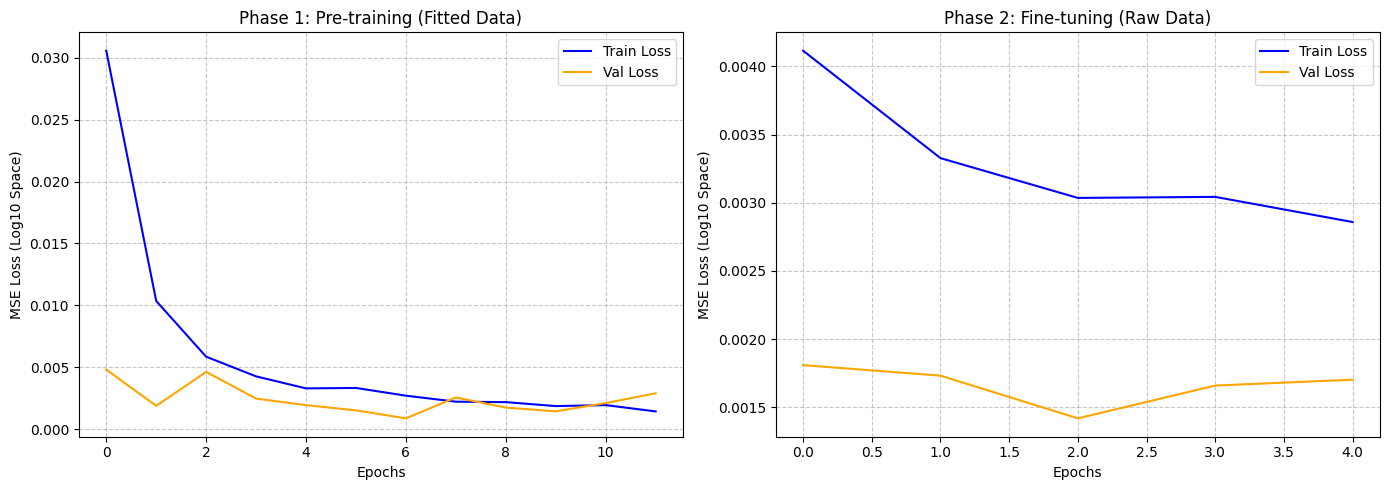

In [1]:
import joblib
import matplotlib.pyplot as plt

# Load the saved histories
history_fit = joblib.load('pretraining_history.joblib')
history_raw = joblib.load('fine_tuning_history.joblib')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Phase 1 (Fitted Data)
ax1.plot(history_fit['loss'], label='Train Loss', color='blue')
ax1.plot(history_fit['val_loss'], label='Val Loss', color='orange')
ax1.set_title('Phase 1: Pre-training (Fitted Data)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('MSE Loss (Log10 Space)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot Phase 2 (Raw Data)
ax2.plot(history_raw['loss'], label='Train Loss', color='blue')
ax2.plot(history_raw['val_loss'], label='Val Loss', color='orange')
ax2.set_title('Phase 2: Fine-tuning (Raw Data)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('MSE Loss (Log10 Space)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [2]:
import numpy as np
import pickle

train_test_data = np.load('train_test_data.npz')
scalerXraw = pickle.load(open('scalerXraw.pkl', 'rb'))
scaleryraw = pickle.load(open('scaleryraw.pkl', 'rb'))
scalerXfit = pickle.load(open('scalerXfit.pkl', 'rb'))
scaleryfit = pickle.load(open('scaleryfit.pkl', 'rb'))

Xraw_selected_train = train_test_data['Xraw_selected_train']
Xraw_selected_train_scaled = scalerXraw.transform(Xraw_selected_train)  
Xraw_selected_test = train_test_data['Xraw_selected_test']
Xraw_selected_test_scaled = scalerXraw.transform(Xraw_selected_test)

yraw_selected_train = train_test_data['yraw_selected_train']
yraw_selected_train_scaled = scaleryraw.transform(yraw_selected_train.reshape(-1, 1))
yraw_selected_test = train_test_data['yraw_selected_test']
yraw_selected_test_scaled = scaleryraw.transform(yraw_selected_test.reshape(-1, 1))

Xfit_selected_train = train_test_data['Xfit_selected_train']
Xfit_selected_train_scaled = scalerXfit.transform(Xfit_selected_train)
Xfit_selected_test = train_test_data['Xfit_selected_test']
Xfit_selected_test_scaled = scalerXfit.transform(Xfit_selected_test)    

yfit_selected_train = train_test_data['yfit_selected_train']
yfit_selected_train_scaled = scaleryfit.transform(yfit_selected_train.reshape(-1, 1))
yfit_selected_test = train_test_data['yfit_selected_test']
yfit_selected_test_scaled = scaleryfit.transform(yfit_selected_test.reshape(-1, 1)) 

Min and Max j1: 0.0 14.0
Min and Max j2: 0.0 31.0
Min and Max j1 (Test): 0.0 14.0
Min and Max j2 (Test): 0.0 31.0


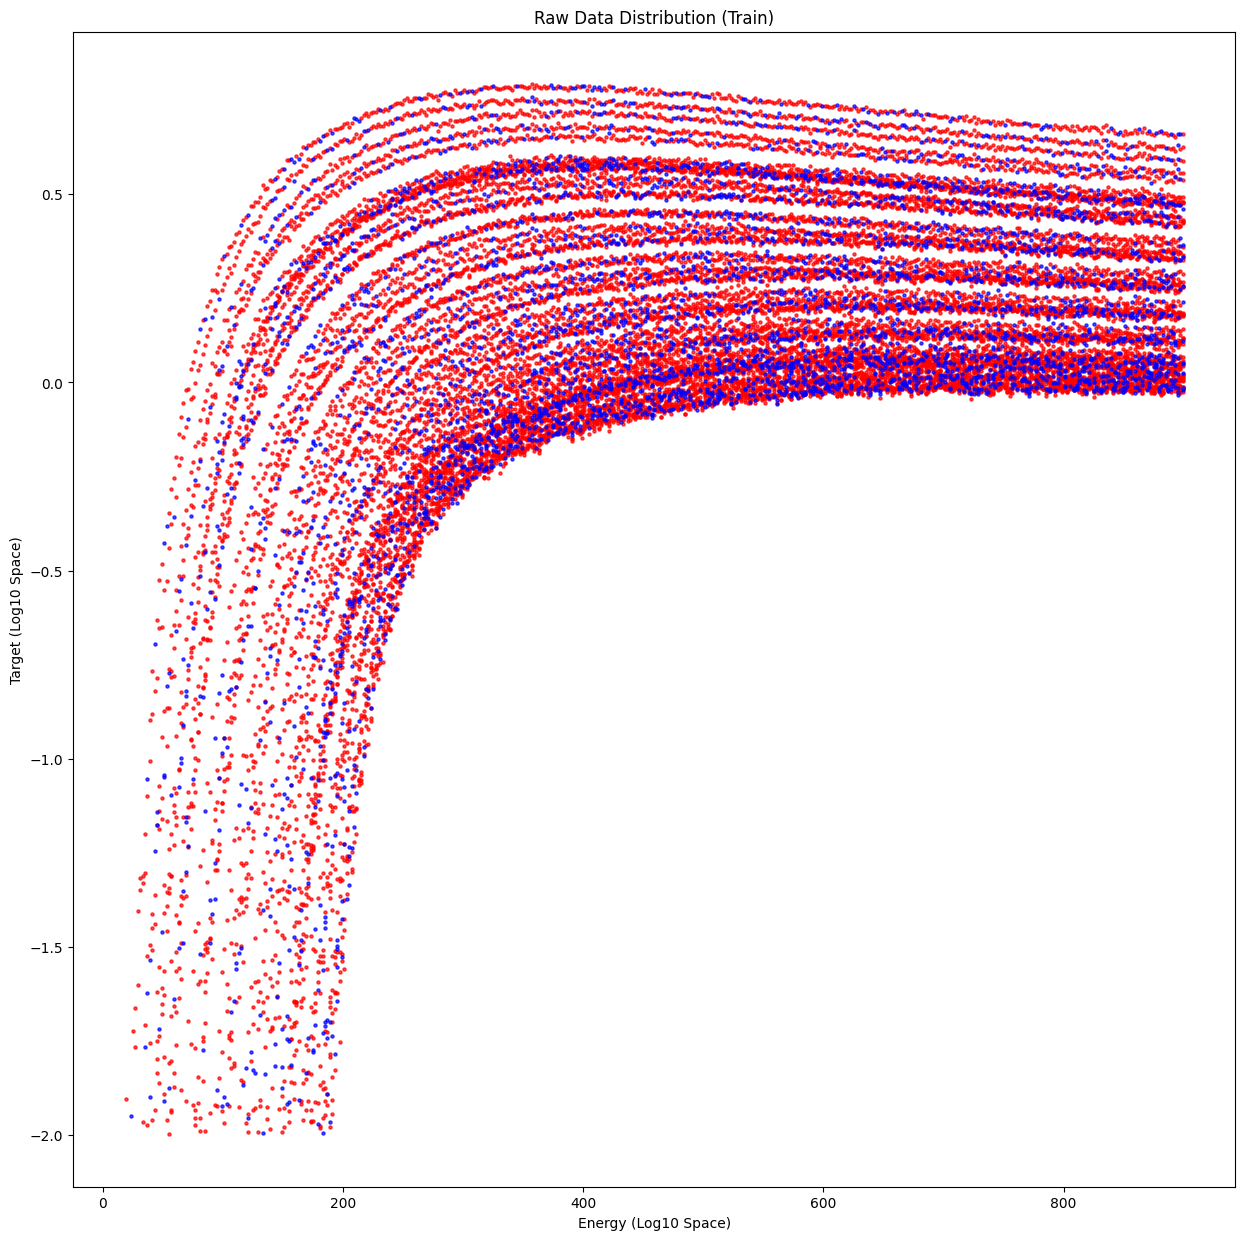

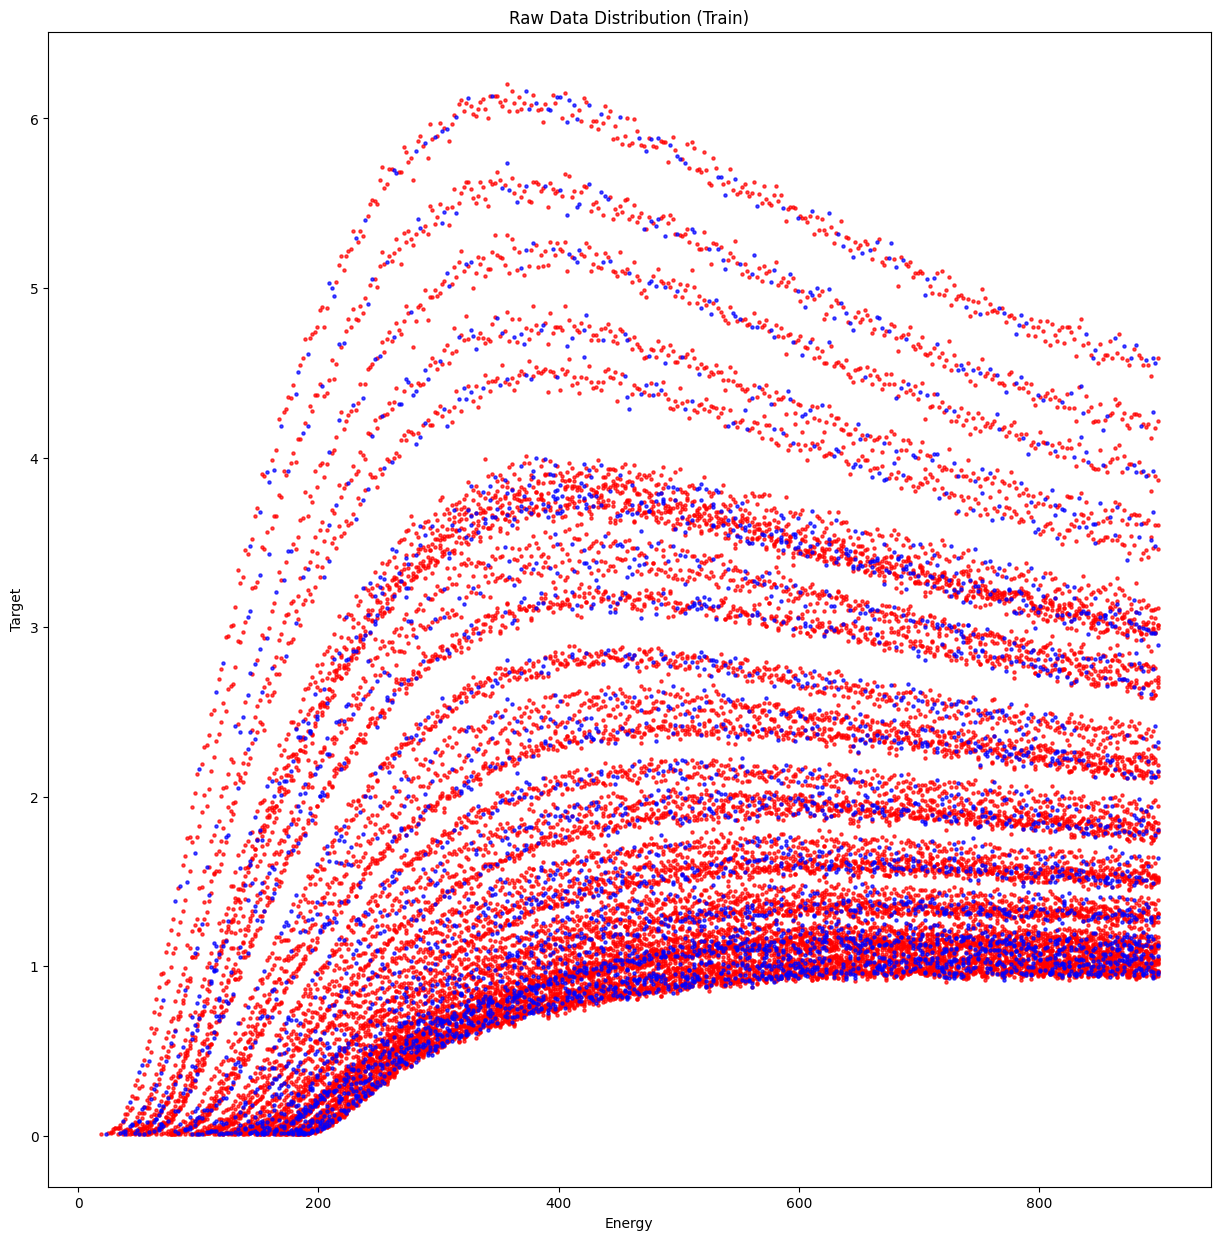

In [3]:
size=5
j1s_raw_train = Xraw_selected_train[:, 0]
j2s_raw_train = Xraw_selected_train[:, 1]
print("Min and Max j1:", min(j1s_raw_train), max(j1s_raw_train))
print("Min and Max j2:", min(j2s_raw_train), max(j2s_raw_train))
j1s_raw_test = Xraw_selected_test[:, 0]
j2s_raw_test = Xraw_selected_test[:, 1]
print("Min and Max j1 (Test):", min(j1s_raw_test), max(j1s_raw_test))
print("Min and Max j2 (Test):", min(j2s_raw_test), max(j2s_raw_test))   

plt.figure(figsize=(15, 15))
for j1 in np.unique(j1s_raw_train):
    for j2 in np.unique(j2s_raw_train):
        selectedindex = np.where((Xraw_selected_train[:, 0] == j1) & (Xraw_selected_train[:, 1] == j2))
        Xraw_subset = Xraw_selected_train[selectedindex]
        eraw = Xraw_subset[:, 2]
        yraw_subset = yraw_selected_train[selectedindex]
        plt.scatter(eraw, yraw_subset, s=size, label="Train", color='red', alpha=0.7)
for j1 in np.unique(j1s_raw_test):
    for j2 in np.unique(j2s_raw_test):
        selectedindex = np.where((Xraw_selected_test[:, 0] == j1) & (Xraw_selected_test[:, 1] == j2))
        Xraw_subset = Xraw_selected_test[selectedindex]
        eraw = Xraw_subset[:, 2]
        yraw_subset = yraw_selected_test[selectedindex]
        plt.scatter(eraw, yraw_subset, s=size, label="Test", color='blue', alpha=0.7)
plt.xlabel('Energy (Log10 Space)')
plt.ylabel('Target (Log10 Space)')
plt.title('Raw Data Distribution (Train)')
plt.show()

plt.figure(figsize=(15, 15))
for j1 in np.unique(j1s_raw_train):
    for j2 in np.unique(j2s_raw_train):
        selectedindex = np.where((Xraw_selected_train[:, 0] == j1) & (Xraw_selected_train[:, 1] == j2))
        Xraw_subset = Xraw_selected_train[selectedindex]
        eraw = Xraw_subset[:, 2]
        yraw_subset = np.pow(10, yraw_selected_train[selectedindex])
        plt.scatter(eraw, yraw_subset, s=size, label="Train", color='red', alpha=0.7)
for j1 in np.unique(j1s_raw_test):
    for j2 in np.unique(j2s_raw_test):
        selectedindex = np.where((Xraw_selected_test[:, 0] == j1) & (Xraw_selected_test[:, 1] == j2))
        Xraw_subset = Xraw_selected_test[selectedindex]
        eraw = Xraw_subset[:, 2]
        yraw_subset = np.pow(10, yraw_selected_test[selectedindex])
        plt.scatter(eraw, yraw_subset, s=size, label="Test", color='blue', alpha=0.7)
plt.xlabel('Energy')
plt.ylabel('Target')
plt.title('Raw Data Distribution (Train)')
plt.show()

Min and Max j1: 0.0 14.0
Min and Max j2: 0.0 31.0
Min and Max j1 (Test): 0.0 14.0
Min and Max j2 (Test): 0.0 31.0


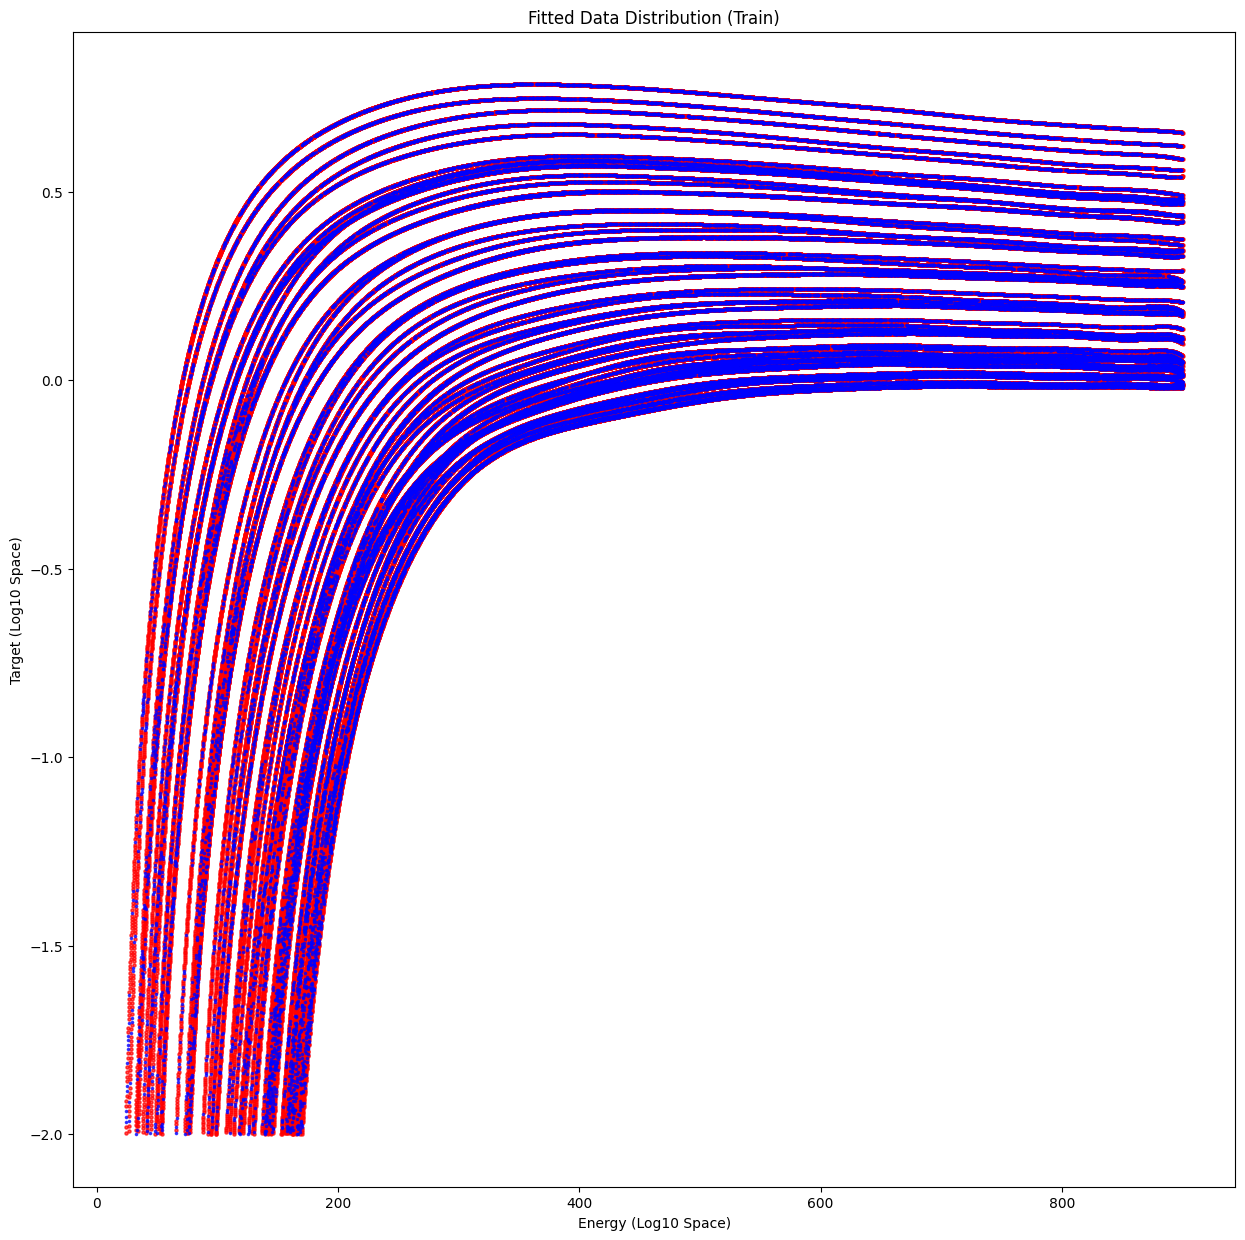

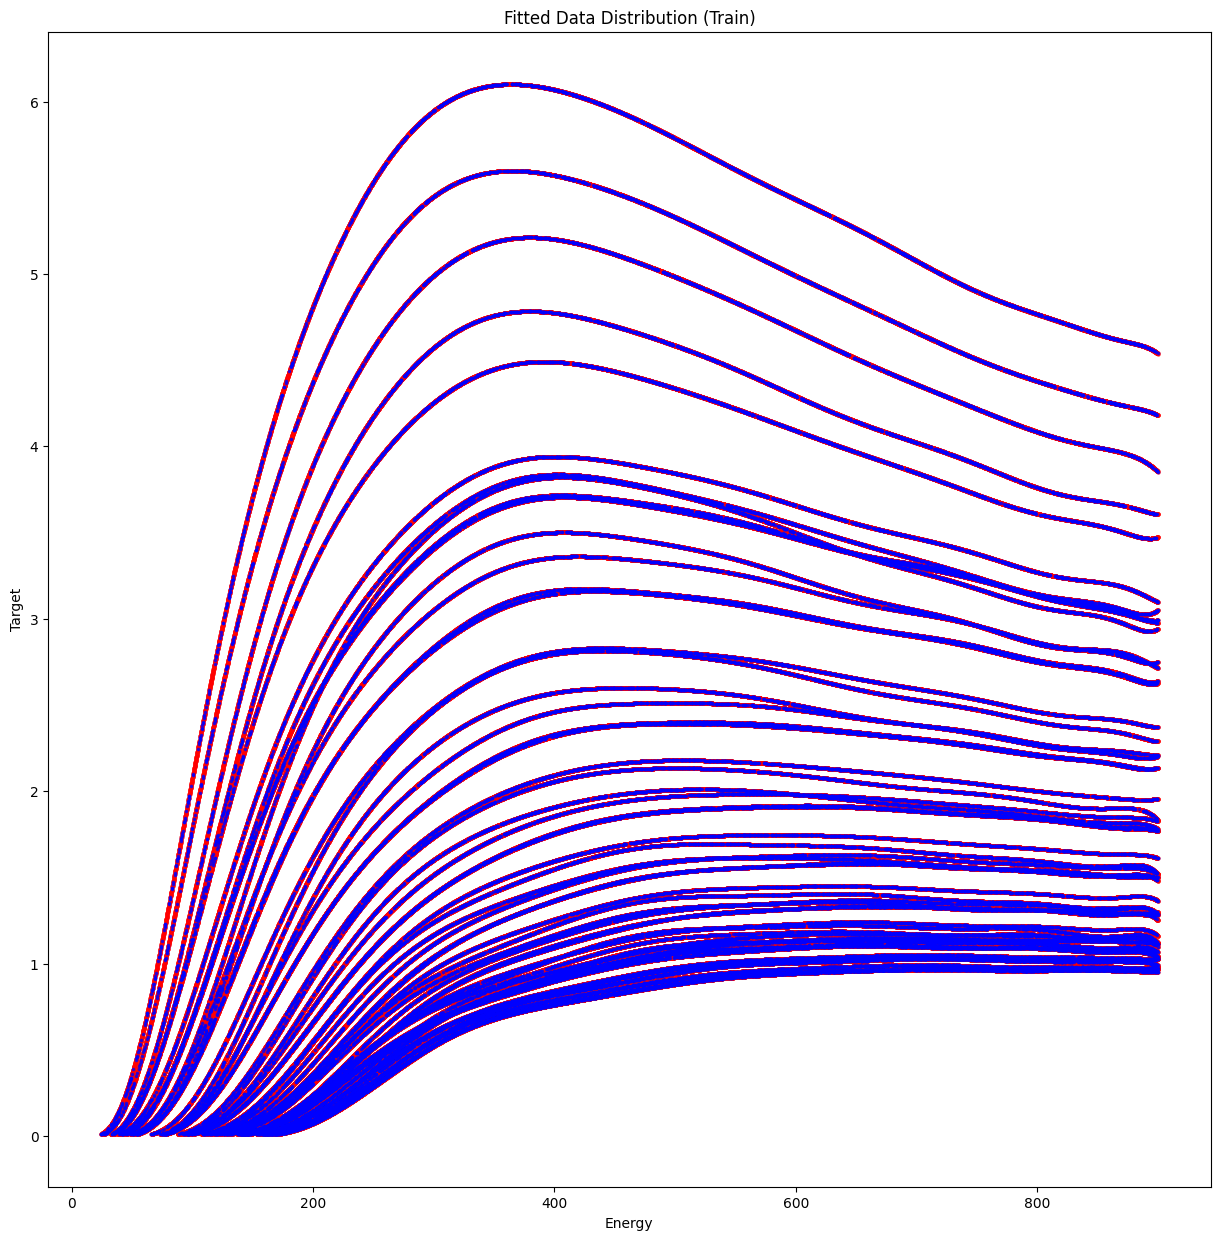

In [4]:
j1s_fit_train = Xfit_selected_train[:, 0]
j2s_fit_train = Xfit_selected_train[:, 1]
print("Min and Max j1:", min(j1s_fit_train), max(j1s_fit_train))
print("Min and Max j2:", min(j2s_fit_train), max(j2s_fit_train))
j1s_fit_test = Xfit_selected_test[:, 0]
j2s_fit_test = Xfit_selected_test[:, 1]
print("Min and Max j1 (Test):", min(j1s_fit_test), max(j1s_fit_test))
print("Min and Max j2 (Test):", min(j2s_fit_test), max(j2s_fit_test))

plt.figure(figsize=(15, 15))
for j1 in np.unique(j1s_fit_train):
    for j2 in np.unique(j2s_fit_train):
        selectedindex = np.where((Xfit_selected_train[:, 0] == j1) & (Xfit_selected_train[:, 1] == j2))
        Xfit_subset = Xfit_selected_train[selectedindex]
        efit = Xfit_subset[:, 2]
        yfit_subset = yfit_selected_train[selectedindex]
        plt.scatter(efit, yfit_subset, s=size, label="Train", color='red', alpha=0.7)
for j1 in np.unique(j1s_fit_test):
    for j2 in np.unique(j2s_fit_test):
        selectedindex = np.where((Xfit_selected_test[:, 0] == j1) & (Xfit_selected_test[:, 1] == j2))
        Xfit_subset = Xfit_selected_test[selectedindex]
        efit = Xfit_subset[:, 2]
        yfit_subset = yfit_selected_test[selectedindex]
        plt.scatter(efit, yfit_subset, s=size/2, label="Test", color='blue', alpha=0.7)
plt.xlabel('Energy (Log10 Space)')
plt.ylabel('Target (Log10 Space)')  
plt.title('Fitted Data Distribution (Train)')
plt.show()

plt.figure(figsize=(15, 15))
for j1 in np.unique(j1s_fit_train):
    for j2 in np.unique(j2s_fit_train):
        selectedindex = np.where((Xfit_selected_train[:, 0] == j1) & (Xfit_selected_train[:, 1] == j2))
        Xfit_subset = Xfit_selected_train[selectedindex]
        efit = Xfit_subset[:, 2]
        yfit_subset = np.pow(10, yfit_selected_train[selectedindex])
        plt.scatter(efit, yfit_subset, s=size, label="Train", color='red', alpha=0.7)
for j1 in np.unique(j1s_fit_test):
    for j2 in np.unique(j2s_fit_test):
        selectedindex = np.where((Xfit_selected_test[:, 0] == j1) & (Xfit_selected_test[:, 1] == j2))
        Xfit_subset = Xfit_selected_test[selectedindex]
        efit = Xfit_subset[:, 2]
        yfit_subset = np.pow(10, yfit_selected_test[selectedindex])
        plt.scatter(efit, yfit_subset, s=size/2, label="Test", color='blue', alpha=0.7)
plt.xlabel('Energy')
plt.ylabel('Target')
plt.title('Fitted Data Distribution (Train)')
plt.show()  

I0000 00:00:1776345552.009329  506762 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776345552.040662  506762 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776345552.752822  506762 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


  1/148 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step

W0000 00:00:1776345553.047128  506762 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 858us/step
589/589 ━━━━━━━━━━━━━━━━━━━━ 0s 444us/step
Pretrained Model Performance on Raw Data:
RMSE (Train): 0.0418, (Test): 0.0440
 MAE (Train): 0.0180, (Test): 0.0181
  R² (Train): 0.9904, (Test): 0.9895


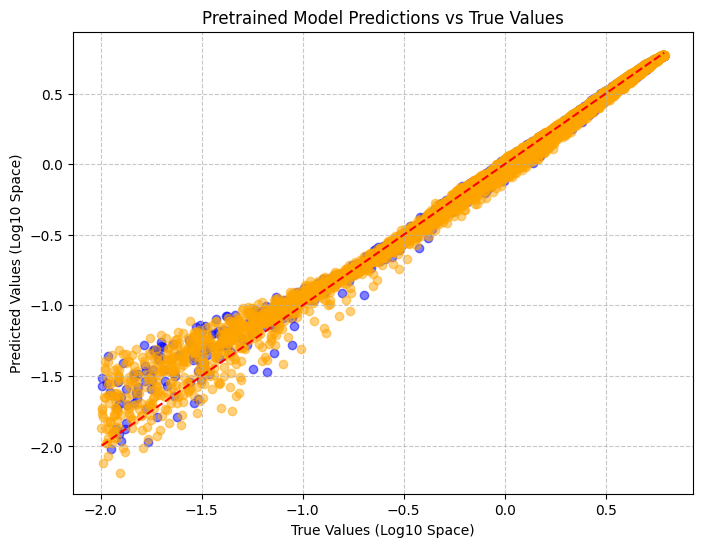

2969/2969 ━━━━━━━━━━━━━━━━━━━━ 1s 418us/step
11876/11876 ━━━━━━━━━━━━━━━━━━━━ 5s 430us/step
Pretrained Model Performance on Fitted Data:
RMSE (Train): 0.0128, (Test): 0.0129
 MAE (Train): 0.0076, (Test): 0.0076
  R² (Train): 0.9991, (Test): 0.9991


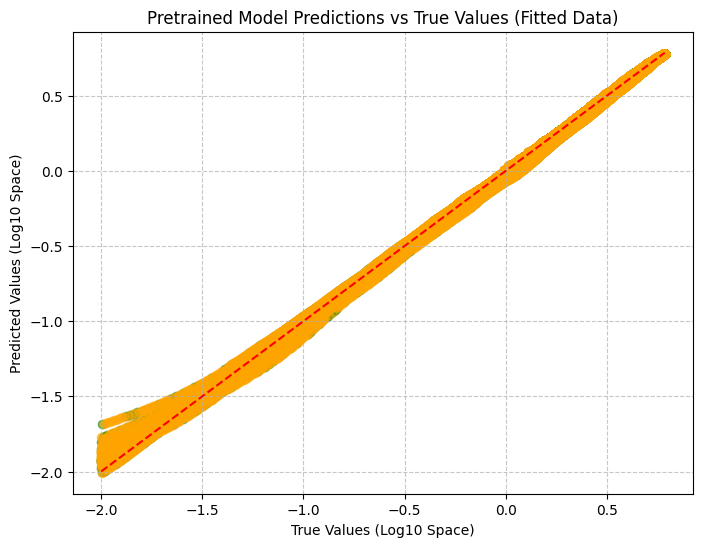

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pretrained_model= joblib.load('pretrained_model.joblib')
predictions_scaled_test = pretrained_model.predict(Xraw_selected_test_scaled)
predictions_scaled_train = pretrained_model.predict(Xraw_selected_train_scaled)
predictions_test = scaleryraw.inverse_transform(predictions_scaled_test.reshape(-1, 1))
predictions_train = scaleryraw.inverse_transform(predictions_scaled_train.reshape(-1, 1))
rmse_train = np.sqrt(np.mean((yraw_selected_train - predictions_train.flatten()) ** 2))
rmse_test = np.sqrt(np.mean((yraw_selected_test - predictions_test.flatten()) ** 2))
mae_train = np.mean(np.abs(yraw_selected_train - predictions_train.flatten()))
mae_test = np.mean(np.abs(yraw_selected_test - predictions_test.flatten()))
r2_train = 1 - np.sum((yraw_selected_train - predictions_train.flatten()) ** 2) \
    / np.sum((yraw_selected_train - np.mean(yraw_selected_train)) ** 2)
r2_test = 1 - np.sum((yraw_selected_test - predictions_test.flatten()) ** 2) \
    / np.sum((yraw_selected_test - np.mean(yraw_selected_test)) ** 2)
print(f"Pretrained Model Performance on Raw Data:")
print(f"RMSE (Train): {rmse_train:.4f}, (Test): {rmse_test:.4f}")
print(f" MAE (Train): {mae_train:.4f}, (Test): {mae_test:.4f}")
print(f"  R² (Train): {r2_train:.4f}, (Test): {r2_test:.4f}")
plt.figure(figsize=(8, 6))
plt.scatter(yraw_selected_test, predictions_test, color='blue', alpha=0.5)
plt.scatter(yraw_selected_train, predictions_train, color='orange', alpha=0.5)
plt.plot([yraw_selected_test.min(), yraw_selected_test.max()], [yraw_selected_test.min(), yraw_selected_test.max()], 'r--')
plt.xlabel('True Values (Log10 Space)')
plt.ylabel('Predicted Values (Log10 Space)')
plt.title('Pretrained Model Predictions vs True Values')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
predictions_scaled_fit = pretrained_model.predict(Xfit_selected_test_scaled)
predictions_fit_test = scaleryfit.inverse_transform(predictions_scaled_fit.reshape(-1, 1))
predictions_scaled_train = pretrained_model.predict(Xfit_selected_train_scaled)
predictions_fit_train = scaleryfit.inverse_transform(predictions_scaled_train.reshape(-1,   1))
rmse_train_fit = np.sqrt(np.mean((yfit_selected_train - predictions_fit_train.flatten()) ** 2))
rmse_test_fit = np.sqrt(np.mean((yfit_selected_test - predictions_fit_test.flatten()) ** 2))
mae_train_fit = np.mean(np.abs(yfit_selected_train - predictions_fit_train.flatten()))
mae_test_fit = np.mean(np.abs(yfit_selected_test - predictions_fit_test.flatten()))
r2_train_fit = 1 - np.sum((yfit_selected_train - predictions_fit_train.flatten()) ** 2) / np.sum((yfit_selected_train - np.mean(yfit_selected_train)) ** 2)
r2_test_fit = 1 - np.sum((yfit_selected_test - predictions_fit_test.flatten()) ** 2) / np.sum((yfit_selected_test - np.mean(yfit_selected_test)) ** 2)
print(f"Pretrained Model Performance on Fitted Data:")
print(f"RMSE (Train): {rmse_train_fit:.4f}, (Test): {rmse_test_fit:.4f}")
print(f" MAE (Train): {mae_train_fit:.4f}, (Test): {mae_test_fit:.4f}")
print(f"  R² (Train): {r2_train_fit:.4f}, (Test): {r2_test_fit:.4f}")    
plt.figure(figsize=(8, 6))
plt.scatter(yfit_selected_test, predictions_fit_test, color='green', alpha=0.5)
plt.scatter(yfit_selected_train, predictions_fit_train, color='orange', alpha=0.5)
plt.plot([yfit_selected_test.min(), yfit_selected_test.max()], [yfit_selected_test.min(), yfit_selected_test.max()], 'r--')
plt.xlabel('True Values (Log10 Space)')
plt.ylabel('Predicted Values (Log10 Space)')
plt.title('Pretrained Model Predictions vs True Values (Fitted Data)')          
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step
589/589 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step
Fine-tuned Model Performance on Raw Data:
RMSE (Train): 0.0190, (Test): 0.0182
 MAE (Train): 0.0102, (Test): 0.0099
  R² (Train): 0.9980, (Test): 0.9982


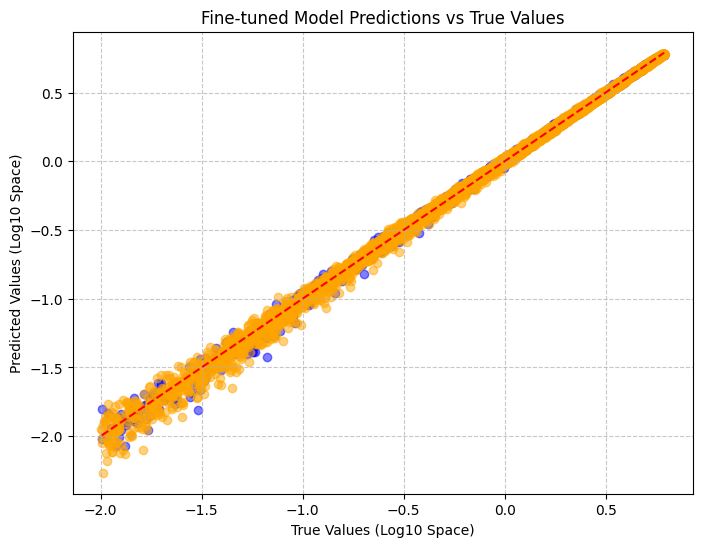

2969/2969 ━━━━━━━━━━━━━━━━━━━━ 1s 428us/step
11876/11876 ━━━━━━━━━━━━━━━━━━━━ 5s 431us/step
Fine-tuned Model Performance on Fitted Data:
RMSE (Train): 0.0467, (Test): 0.0469
 MAE (Train): 0.0147, (Test): 0.0147
  R² (Train): 0.9886, (Test): 0.9885


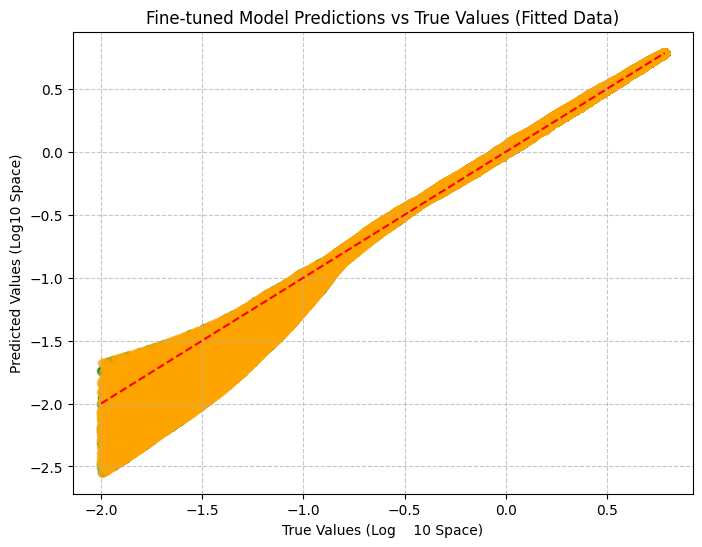

In [6]:
fine_tuned_model = joblib.load('fine_tuned_model.joblib')
predictions_scaled_test = fine_tuned_model.predict(Xraw_selected_test_scaled)
predictions_test = scaleryraw.inverse_transform(predictions_scaled_test.reshape(-1, 1))
predictions_scaled_train = fine_tuned_model.predict(Xraw_selected_train_scaled)
predictions_train = scaleryraw.inverse_transform(predictions_scaled_train.reshape(-1, 1))   
rmse_train_ft = np.sqrt(np.mean((yraw_selected_train - predictions_train.flatten()) ** 2))
rmse_test_ft = np.sqrt(np.mean((yraw_selected_test - predictions_test.flatten()) ** 2))
mae_train_ft = np.mean(np.abs(yraw_selected_train - predictions_train.flatten()))
mae_test_ft = np.mean(np.abs(yraw_selected_test - predictions_test.flatten()))
r2_train_ft = 1 - np.sum((yraw_selected_train - predictions_train.flatten()) ** 2) \
    / np.sum((yraw_selected_train - np.mean(yraw_selected_train)) ** 2)
r2_test_ft = 1 - np.sum((yraw_selected_test - predictions_test.flatten()) ** 2) \
    / np.sum((yraw_selected_test - np.mean(yraw_selected_test)) ** 2)                                      
print(f"Fine-tuned Model Performance on Raw Data:")
print(f"RMSE (Train): {rmse_train_ft:.4f}, (Test): {rmse_test_ft:.4f}")
print(f" MAE (Train): {mae_train_ft:.4f}, (Test): {mae_test_ft:.4f}")
print(f"  R² (Train): {r2_train_ft:.4f}, (Test): {r2_test_ft:.4f}")
plt.figure(figsize=(8, 6))
plt.scatter(yraw_selected_test, predictions_test, color='blue', alpha=0.5)
plt.scatter(yraw_selected_train, predictions_train, color='orange', alpha=0.5)
plt.plot([yraw_selected_test.min(), yraw_selected_test.max()], [yraw_selected_test.min(), yraw_selected_test.max()], 'r--')
plt.xlabel('True Values (Log10 Space)')
plt.ylabel('Predicted Values (Log10 Space)')
plt.title('Fine-tuned Model Predictions vs True Values')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
predictions_scaled_fit_test = fine_tuned_model.predict(Xfit_selected_test_scaled)
predictions_fit_test = scaleryfit.inverse_transform(predictions_scaled_fit_test.reshape(-1, 1))
predictions_scaled_fit_train = fine_tuned_model.predict(Xfit_selected_train_scaled)
predictions_fit_train = scaleryfit.inverse_transform(predictions_scaled_fit_train.reshape(-1, 1))
rmse_train_fit_ft = np.sqrt(np.mean((yfit_selected_train - predictions_fit_train.flatten()) ** 2))
rmse_test_fit_ft = np.sqrt(np.mean((yfit_selected_test - predictions_fit_test.flatten()) ** 2))
mae_train_fit_ft = np.mean(np.abs(yfit_selected_train - predictions_fit_train.flatten()))
mae_test_fit_ft = np.mean(np.abs(yfit_selected_test - predictions_fit_test.flatten()))
r2_train_fit_ft = 1 - np.sum((yfit_selected_train - predictions_fit_train.flatten()) ** 2) / np.sum((yfit_selected_train - np.mean(yfit_selected_train)) ** 2)
r2_test_fit_ft = 1 - np.sum((yfit_selected_test - predictions_fit_test.flatten()) ** 2) / np.sum((yfit_selected_test - np.mean(yfit_selected_test)) ** 2)
print(f"Fine-tuned Model Performance on Fitted Data:")
print(f"RMSE (Train): {rmse_train_fit_ft:.4f}, (Test): {rmse_test_fit_ft:.4f}")
print(f" MAE (Train): {mae_train_fit_ft:.4f}, (Test): {mae_test_fit_ft:.4f}")
print(f"  R² (Train): {r2_train_fit_ft:.4f}, (Test): {r2_test_fit_ft:.4f}")   
plt.figure(figsize=(8, 6))
plt.scatter(yfit_selected_test, predictions_fit_test, color='green', alpha=0.5)
plt.scatter(yfit_selected_train, predictions_fit_train, color='orange', alpha=0.5)
plt.plot([yfit_selected_test.min(), yfit_selected_test.max()], [yfit_selected_test.min(), yfit_selected_test.max()], 'r--')
plt.xlabel('True Values (Log    10 Space)')
plt.ylabel('Predicted Values (Log10 Space)')
plt.title('Fine-tuned Model Predictions vs True Values (Fitted Data)')          
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


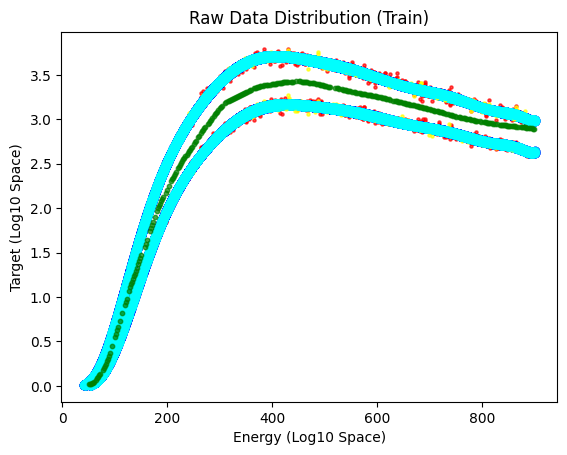

In [8]:
# prediction for (v=10,j=2)+(v=0,j=30)
j1pred = 2
j2pred = 30

j1s= [0, 1]
j2s = [29, 31]
selectedindex = np.where((Xraw_selected_train[:, 0] == j1s[0]) \
                         & (Xraw_selected_train[:, 1] == j2s[0]))
Xraw_subset = Xraw_selected_train[selectedindex]
evalues = Xraw_subset[:, 2]

X_pres = np.array([[j1pred, j2pred, e] for e in evalues])
X_pres_scaled = scalerXraw.transform(X_pres)
predictions_scaled = fine_tuned_model.predict(X_pres_scaled)
predictions = scaleryraw.inverse_transform(predictions_scaled.reshape(-1, 1))
#print(f"Predictions for (v={j1pred}, j={j2pred}) at different energies:")
#for e, pred in zip(evalues, predictions.flatten()):
#    print(f"Energy: {e:.2f}, Predicted Target: {pred:.4f}")

for j1 in j1s:
    for j2 in j2s:
        selectedindex = np.where((Xraw_selected_train[:, 0] == j1) & (Xraw_selected_train[:, 1] == j2))
        Xraw_subset = Xraw_selected_train[selectedindex]
        eraw = Xraw_subset[:, 2]
        yraw_subset = yraw_selected_train[selectedindex]
        yraw_subset = np.pow(10, yraw_subset)
        plt.scatter(eraw, yraw_subset, s=size, label="Train", color='red', alpha=0.7)
        selectedindex = np.where((Xfit_selected_train[:, 0] == j1) & (Xfit_selected_train[:, 1] == j2))
        Xfit_subset = Xfit_selected_train[selectedindex]
        efit = Xfit_subset[:, 2]
        yfit_subset = yfit_selected_train[selectedindex]
        yfit_subset = np.pow(10, yfit_subset)
        plt.scatter(efit, yfit_subset, linewidths=1, label="Train (Fitted)", color='blue', alpha=0.7) 
for j1 in j1s:
    for j2 in j2s:
        selectedindex = np.where((Xraw_selected_test[:, 0] == j1) & (Xraw_selected_test[:, 1] == j2))
        Xraw_subset = Xraw_selected_test[selectedindex]
        eraw = Xraw_subset[:, 2]
        yraw_subset = yraw_selected_test[selectedindex]
        yraw_subset = np.pow(10, yraw_subset)
        plt.scatter(eraw, yraw_subset, s=size, label="Test", color='yellow', alpha=0.7)
        selectedindex = np.where((Xfit_selected_test[:, 0] == j1) & (Xfit_selected_test[:, 1] == j2))
        Xfit_subset = Xfit_selected_test[selectedindex]
        efit = Xfit_subset[:, 2]
        yfit_subset = yfit_selected_test[selectedindex]
        yfit_subset = np.pow(10, yfit_subset)
        plt.scatter(efit, yfit_subset, linewidths=1, label="Test (Fitted)", color='cyan', alpha=0.7)    
plt.scatter(evalues, np.pow(10, predictions.flatten()), s=size*2, label="Predictions (v=10,j=2)+(v=0,j=30)", color='green', alpha=0.7)  
plt.xlabel('Energy (Log10 Space)')
plt.ylabel('Target (Log10 Space)')
plt.title('Raw Data Distribution (Train)')
plt.show()